## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

## Loading Data And EDA

In [23]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df = df.copy()

print(f'{df.head()}\n')
print(f'shape : \n{df.shape}\n')
print(f'Data info \n{df.info()}\n')
print(f"Data description :\n{df.describe()}\n")
print(f"Null Report\n{df.isnull().sum()}\n")
print(f'Dupulicate Data Report :\n{df.duplicated().sum()}')

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

## INITIAL CLEANING (DROP USELESS COLUMNS)

In [24]:
drop_cols = ['OrderID', 'CustomerID', 'TrackingNumber', 'ShippingAddress']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

In [25]:
df.head(5)

,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,2023-01-04,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10
1,2024-08-23,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70
2,2024-02-27,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40
3,2023-10-15,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19
4,2025-05-08,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04


## FEATURE ENGINEERING

In [26]:


# 1. Date Features
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek

    df.drop(columns=['Date'], inplace=True)

# 2. Coupon Feature
if 'CouponCode' in df.columns:
    df['CouponUsed'] = df['CouponCode'].notnull().astype(int)
    df.drop(columns=['CouponCode'], inplace=True)

# 3. Behavioral Feature
if 'UnitPrice' in df.columns and 'ItemsInCart' in df.columns:
    df['CartValue'] = df['UnitPrice'] * df['ItemsInCart']

# 4. Remove Redundant Column
df.drop(columns=['TotalPrice'], inplace=True, errors='ignore')

In [27]:
df.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,ReferralSource,Year,Month,DayOfWeek,CouponUsed,CartValue
0,Monitor,5,570.62,Debit Card,Shipped,7,Instagram,2023,1,2,1,3994.34
1,Phone,2,151.35,Online,Shipped,3,Referral,2024,8,4,1,454.05
2,Tablet,5,550.68,Credit Card,Cancelled,8,Email,2024,2,1,1,4405.44
3,Chair,1,273.19,Debit Card,Returned,5,Facebook,2023,10,6,1,1365.95
4,Printer,4,626.01,Online,Delivered,8,Email,2025,5,3,1,5008.08


## Heatmap for correlations

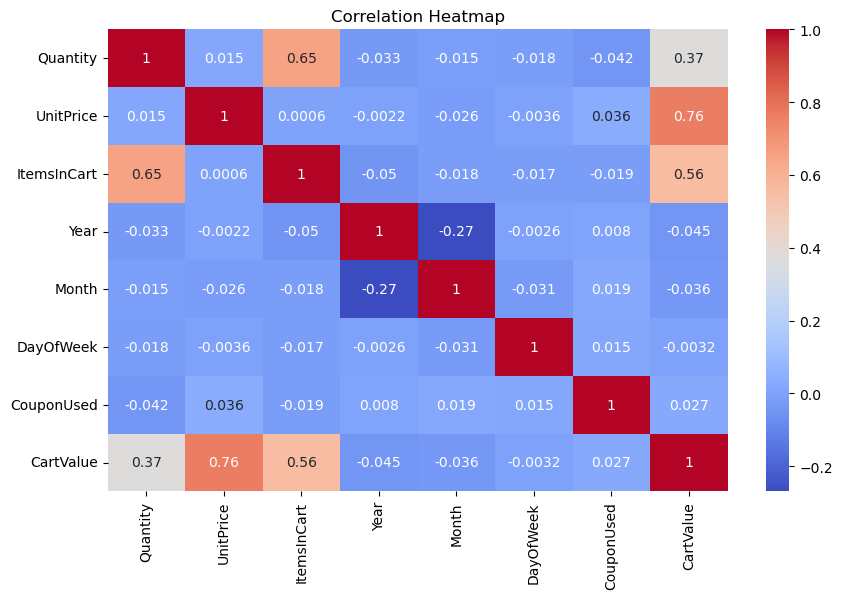

In [28]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## BoxPlot for outlier Detection

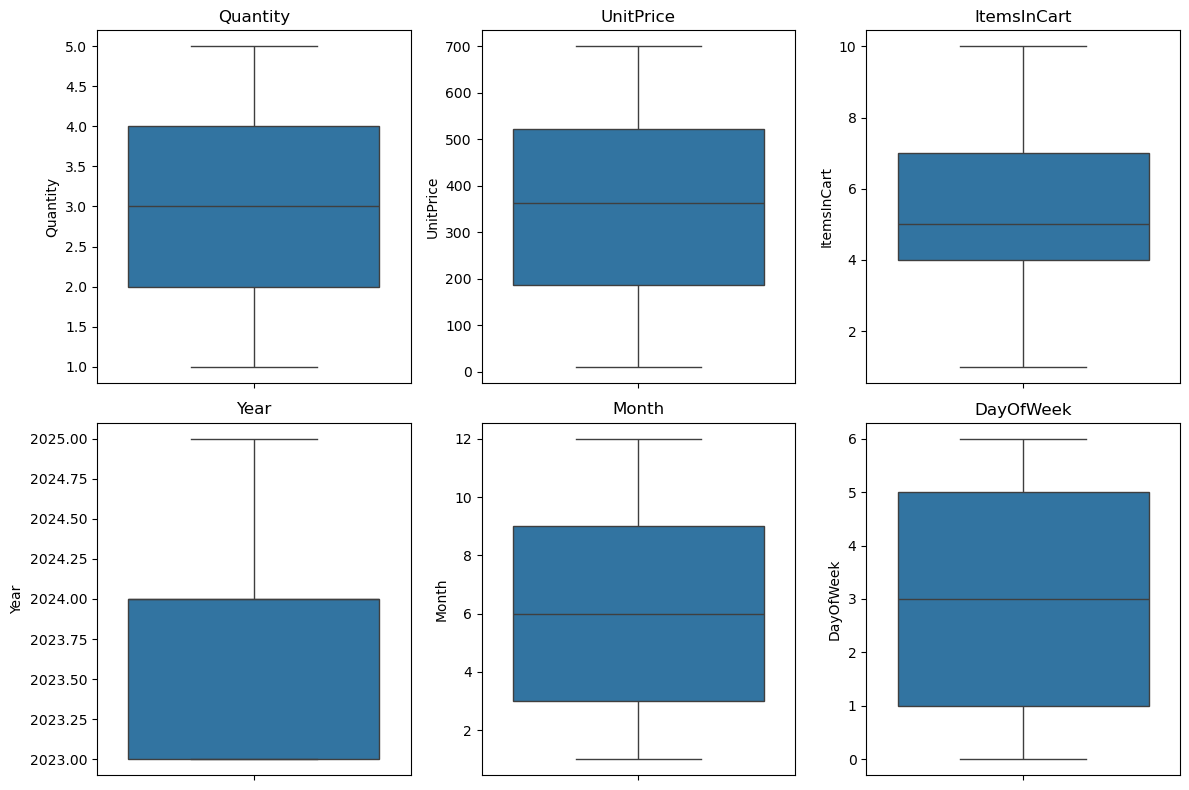

In [29]:
plt.figure(figsize=(12,8))

for i, col in enumerate(num_df.columns[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Defining Target

In [30]:
target = 'OrderStatus'  # change if needed

X = df.drop(columns=[target])
y = df[target]

## Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Column Detection

In [32]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','string']).columns.tolist()

## Numeric Pipeline (Outliers + Scaling)

In [33]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

## Categorical Pipeline (Encoding)

In [34]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine

In [35]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## PCA (DIMENSION REDUCTION)

In [36]:
pca = PCA(n_components=0.90, random_state=42)

## FINAL PIPELINE

In [37]:
final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', pca)
])

## TRANSFORM DATA

In [38]:
X_train_processed = final_pipeline.fit_transform(X_train)
X_test_processed = final_pipeline.transform(X_test)

In [39]:
X_train_processed

array([[ 0.99887237, -0.61398184, -1.19804979, ...,  0.16532603,
         0.41508881, -0.05263382],
       [ 1.05169502,  0.686384  , -0.63093415, ..., -0.84755932,
        -0.47754937,  0.8304302 ],
       [ 1.00158833,  0.47727213, -0.12277779, ...,  0.08652149,
         0.13338085, -0.05460207],
       ...,
       [ 1.0020957 ,  0.7684091 ,  0.35166256, ..., -0.2291731 ,
         0.7615459 , -0.22668259],
       [-3.05235907, -1.14773384, -0.25328801, ...,  0.69197408,
        -0.15143766, -0.12125363],
       [-2.98007895,  0.48647515,  1.30273518, ...,  0.25539838,
         1.01661745, -0.12789466]], shape=(960, 16))

## PCA CURVE (FOR VISUALIZATION)

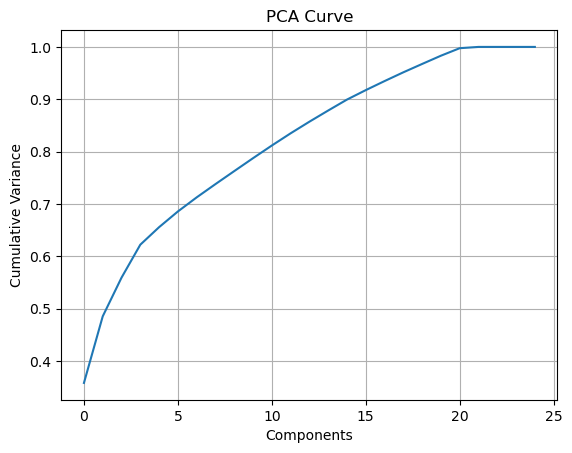

In [40]:
pca_temp = PCA()
X_temp = preprocessor.fit_transform(X_train)

pca_temp.fit(X_temp)

plt.plot(np.cumsum(pca_temp.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Curve")
plt.grid()
plt.show()

## Save As Binary (Faster & Smaller)

In [41]:
joblib.dump(X_train_processed, "X_train_processed.pkl")
joblib.dump(X_test_processed, "X_test_processed.pkl")
joblib.dump(final_pipeline, "preprocessing_pipeline.pkl")

['preprocessing_pipeline.pkl']